In [4]:
import sys, os
sys.path.insert(0, "..")
os.makedirs("../reports/figures", exist_ok=True)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 130

from src.data.load_data import load_arxiv_pyg
from src.models.gcn import build_gcn
from src.models.gat import build_gat
from src.models.graphsage import build_graphsage
from src.training.train_node import train, evaluate, EarlyStopping, CONFIG

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
data, split_idx, evaluator = load_arxiv_pyg(root="../data/raw")
data = data.to(DEVICE)
split_idx = {k: v.to(DEVICE) for k, v in split_idx.items()}
print("✓ Data ready")

[PyG] ogbn-arxiv | Nodes: 169,343 | Edges: 1,166,243 | Features: 128 | Classes: 40
✓ Data ready


d:\graph-ml-gnn-analysis\.venv\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


In [5]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def run_experiment(model_name, epochs=300, patience=30):
    """Train one model and return full learning curves + best results."""
    model_map = {"gcn": build_gcn, "gat": build_gat, "graphsage": build_graphsage}
    model = model_map[model_name]().to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5,
                                  patience=10, min_lr=1e-5)

    checkpoint = f"../experiments/results/{model_name}_exp.pt"
    stopper = EarlyStopping(patience=patience, checkpoint_path=checkpoint)

    history = {"loss": [], "train": [], "valid": [], "test": []}

    for epoch in tqdm(range(1, epochs + 1), desc=model_name.upper()):
        loss = train(model, data, optimizer, split_idx)
        results = evaluate(model, data, split_idx, evaluator)
        scheduler.step(results["valid"])

        history["loss"].append(loss)
        history["train"].append(results["train"])
        history["valid"].append(results["valid"])
        history["test"].append(results["test"])

        if stopper.step(results["valid"], model, epoch):
            print(f"  Early stop @ epoch {epoch} | best val @ {stopper.best_epoch}")
            break

    best_idx = np.argmax(history["valid"])
    return {
        "model":      model_name.upper(),
        "best_epoch": stopper.best_epoch,
        "train_acc":  history["train"][best_idx],
        "val_acc":    history["valid"][best_idx],
        "test_acc":   history["test"][best_idx],
        "params":     sum(p.numel() for p in model.parameters()),
        "history":    history,
    }

# Run all three — takes ~30-60 min on CPU total
# If GraphSAGE already trained, it will re-train for fair comparison
results = {}
for name in ["gcn", "gat", "graphsage"]:
    results[name] = run_experiment(name, epochs=300, patience=30)
    print(f"✓ {name.upper()} done — Test Acc: {results[name]['test_acc']:.4f}\n")


GCN:  87%|█████████████████████████████████████████████████████████████████▌         | 262/300 [1:26:24<12:31, 19.79s/it]


  Early stop @ epoch 263 | best val @ 233
✓ GCN done — Test Acc: 0.5496




GAT:  60%|███████████████████████████████████████████▍                            | 181/300 [6:45:15<4:26:26, 134.34s/it]

  Early stop @ epoch 182 | best val @ 152
✓ GAT done — Test Acc: 0.5525





GRAPHSAGE:  81%|█████████████████████████████████████████████████████▋            | 244/300 [9:53:27<2:16:12, 145.93s/it]

  Early stop @ epoch 245 | best val @ 215
✓ GRAPHSAGE done — Test Acc: 0.5693



In [7]:
rows = []
for name, r in results.items():
    rows.append({
        "Model":       r["model"],
        "Test Acc":    f"{r['test_acc']:.4f} ({r['test_acc']*100:.2f}%)",
        "Val Acc":     f"{r['val_acc']:.4f} ({r['val_acc']*100:.2f}%)",
        "Train Acc":   f"{r['train_acc']:.4f} ({r['train_acc']*100:.2f}%)",
        "Best Epoch":  r["best_epoch"],
        "Params":      f"{r['params']:,}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("=" * 70)
print("Model Comparison — ogbn-arxiv Node Classification")
print("=" * 70)
print(df.to_string())

# Save as CSV for report
df.to_csv("../experiments/results/model_comparison.csv")
print("\n✓ Saved → experiments/results/model_comparison.csv")

Model Comparison — ogbn-arxiv Node Classification
                  Test Acc          Val Acc        Train Acc  Best Epoch   Params
Model                                                                            
GCN        0.5496 (54.96%)  0.6098 (60.98%)  0.6635 (66.35%)         233  110,120
GAT        0.5525 (55.25%)  0.6199 (61.99%)  0.6569 (65.69%)         152  702,624
GRAPHSAGE  0.5693 (56.93%)  0.6382 (63.82%)  0.7280 (72.80%)         215  218,664

✓ Saved → experiments/results/model_comparison.csv


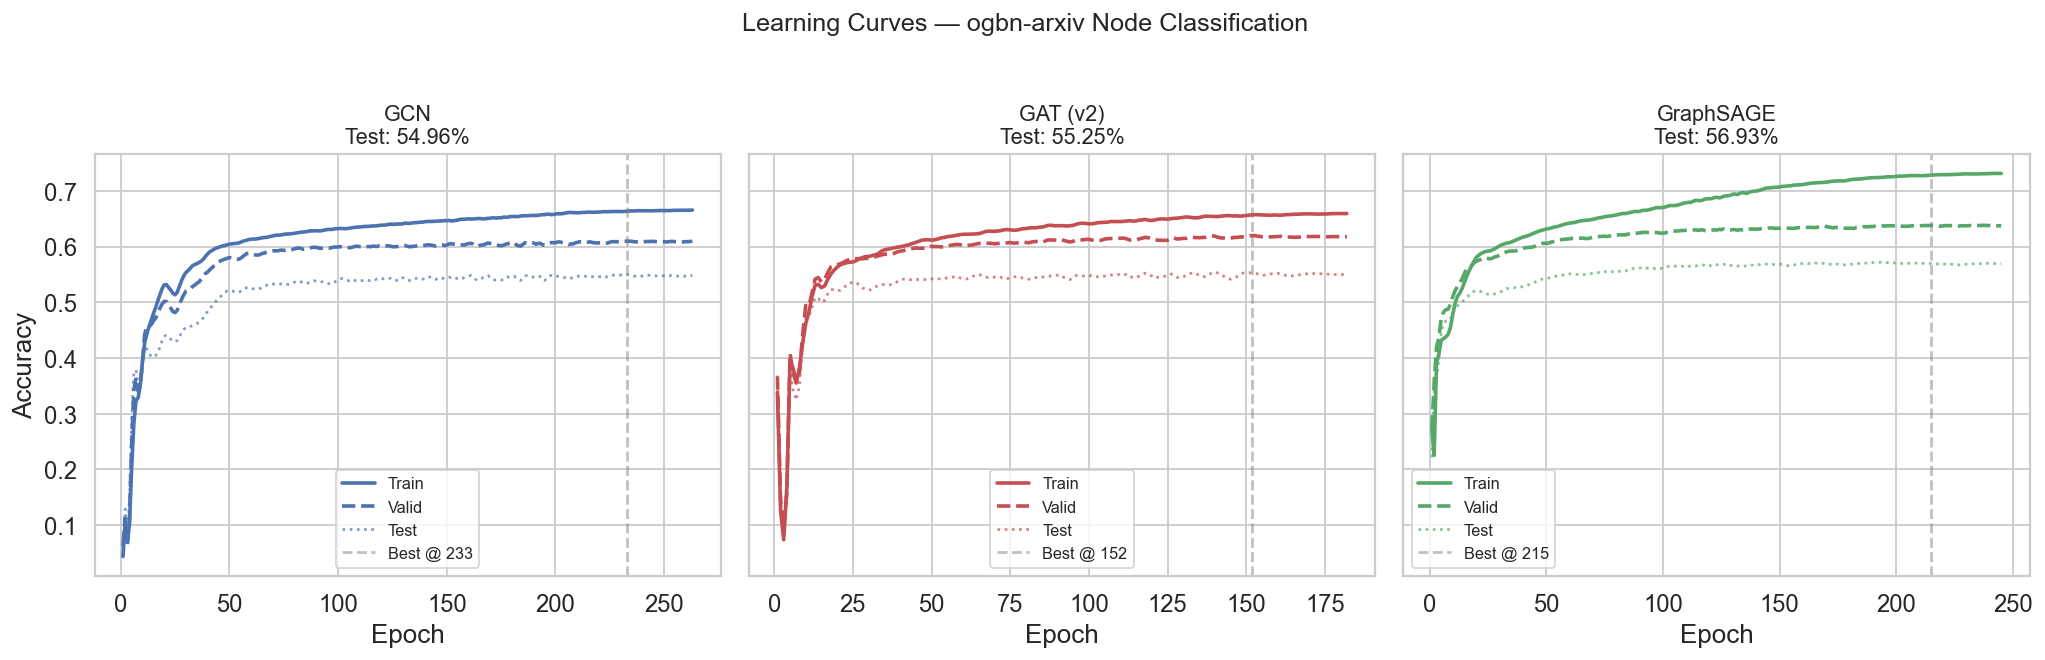

✓ Saved → reports/figures/learning_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

colors = {"gcn": "#4C72B0", "gat": "#C44E52", "graphsage": "#55A868"}
titles = {"gcn": "GCN", "gat": "GAT (v2)", "graphsage": "GraphSAGE"}

for ax, (name, r) in zip(axes, results.items()):
    h = r["history"]
    epochs = range(1, len(h["train"]) + 1)

    ax.plot(epochs, h["train"], label="Train", color=colors[name], linewidth=2)
    ax.plot(epochs, h["valid"], label="Valid", color=colors[name],
            linewidth=2, linestyle="--")
    ax.plot(epochs, h["test"],  label="Test",  color=colors[name],
            linewidth=1.5, linestyle=":", alpha=0.7)
    ax.axvline(r["best_epoch"], color="gray", linestyle="--",
               alpha=0.5, label=f"Best @ {r['best_epoch']}")
    ax.set_title(f"{titles[name]}\nTest: {r['test_acc']*100:.2f}%", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Accuracy")
plt.suptitle("Learning Curves — ogbn-arxiv Node Classification", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → reports/figures/learning_curves.png")

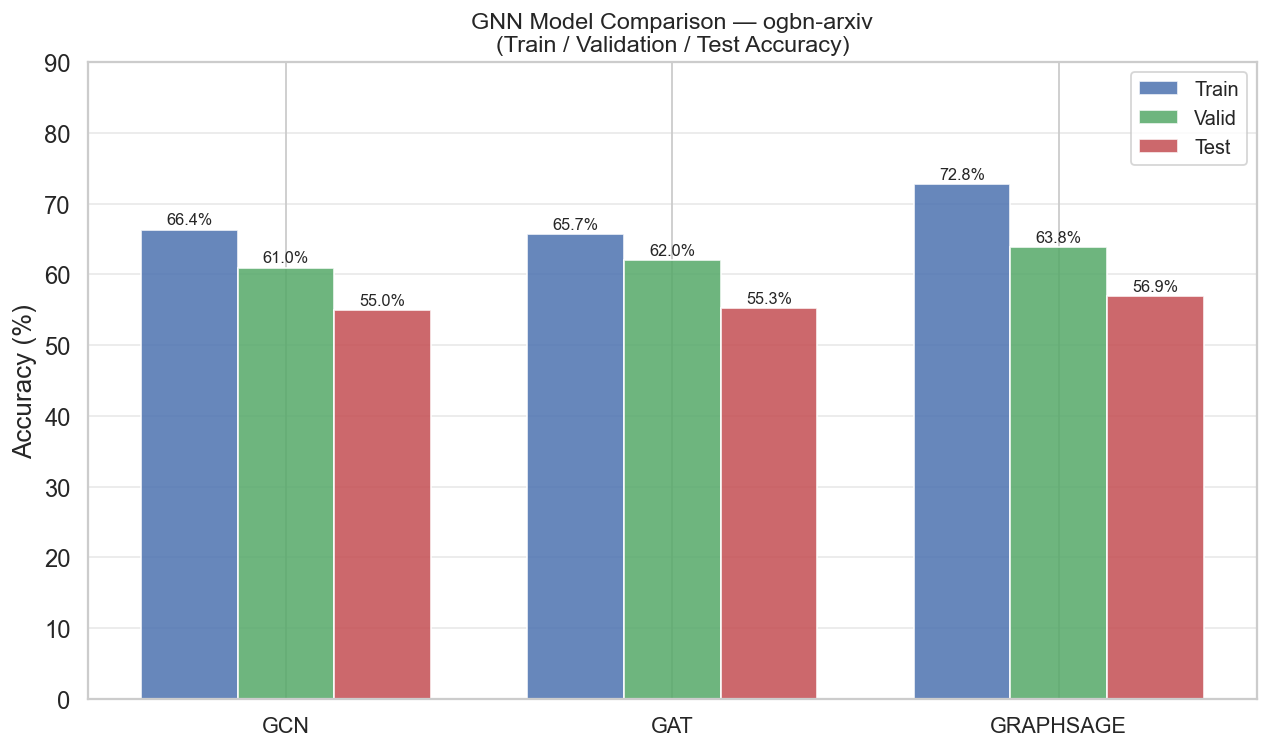

✓ Saved → reports/figures/model_comparison_bar.png


In [9]:
models     = [r["model"] for r in results.values()]
test_accs  = [r["test_acc"] * 100 for r in results.values()]
val_accs   = [r["val_acc"]  * 100 for r in results.values()]
train_accs = [r["train_acc"] * 100 for r in results.values()]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, train_accs, width, label="Train", color="#4C72B0", alpha=0.85)
b2 = ax.bar(x,         val_accs,   width, label="Valid", color="#55A868", alpha=0.85)
b3 = ax.bar(x + width, test_accs,  width, label="Test",  color="#C44E52", alpha=0.85)

# Value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 90)
ax.set_title("GNN Model Comparison — ogbn-arxiv\n(Train / Validation / Test Accuracy)",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → reports/figures/model_comparison_bar.png")

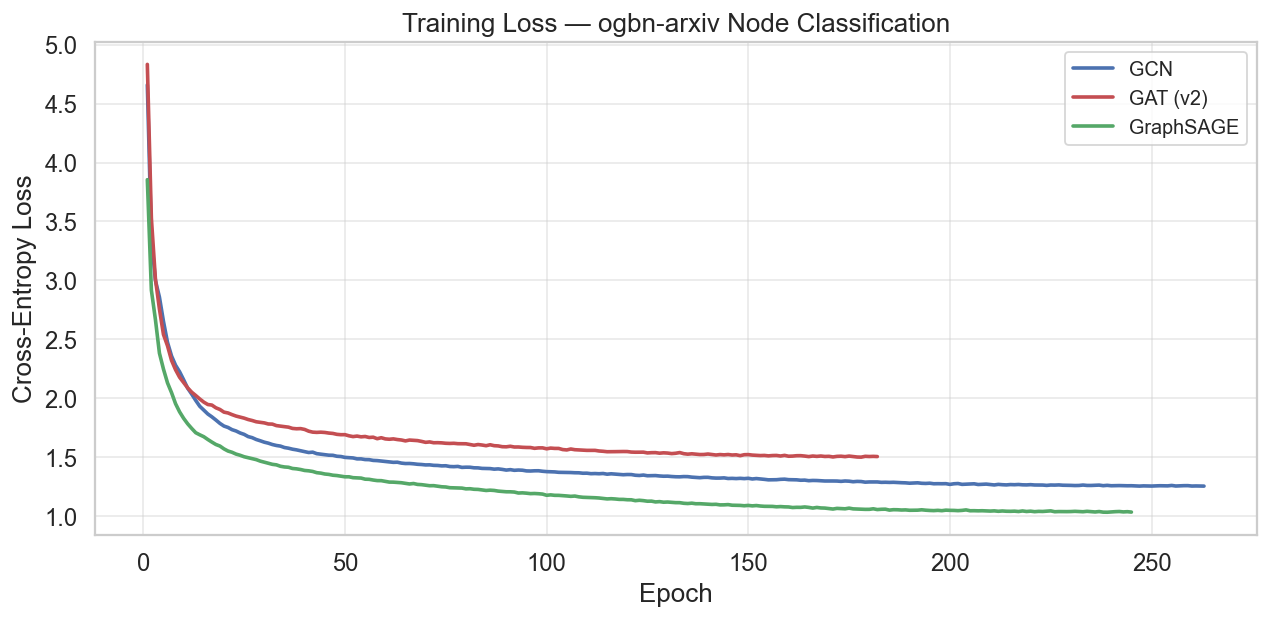

✓ Saved → reports/figures/loss_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, r in results.items():
    epochs = range(1, len(r["history"]["loss"]) + 1)
    ax.plot(epochs, r["history"]["loss"],
            label=titles[name], color=colors[name], linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss — ogbn-arxiv Node Classification")
ax.legend(fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/figures/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → reports/figures/loss_curves.png")

In [11]:
def run_depth_ablation(num_layers_list, epochs=200, patience=25):
    depth_results = {}
    for nl in num_layers_list:
        from src.models.graphsage import GraphSAGE
        model = GraphSAGE(
            in_channels=128, hidden_channels=256,
            out_channels=40, num_layers=nl, dropout=0.5
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=10)
        stopper = EarlyStopping(
            patience=patience,
            checkpoint_path=f"../experiments/results/sage_depth_{nl}.pt"
        )

        best_val, best_test = 0.0, 0.0
        for epoch in tqdm(range(1, epochs + 1), desc=f"Layers={nl}", leave=False):
            train(model, data, optimizer, split_idx)
            res = evaluate(model, data, split_idx, evaluator)
            scheduler.step(res["valid"])
            if res["valid"] > best_val:
                best_val, best_test = res["valid"], res["test"]
            if stopper.step(res["valid"], model, epoch):
                break

        depth_results[nl] = {"val": best_val, "test": best_test,
                              "params": sum(p.numel() for p in model.parameters())}
        print(f"  Layers={nl} | Val: {best_val:.4f} | Test: {best_test:.4f}")

    return depth_results

print("Running depth ablation (GraphSAGE with 1–5 layers)...")
depth_results = run_depth_ablation([1, 2, 3, 4, 5])

Running depth ablation (GraphSAGE with 1–5 layers)...



Layers=1:  86%|█████████████████████████████████████████████████████████████▌          | 171/200 [14:58<02:35,  5.38s/it]
                                                                                                                         

  Layers=1 | Val: 0.6301 | Test: 0.5638



Layers=2: 100%|████████████████████████████████████████████████████████████████████████| 200/200 [17:40<00:00,  5.34s/it]
                                                                                                                         

  Layers=2 | Val: 0.6283 | Test: 0.5601


...

  Layers=3 | Val: 0.6366 | Test: 0.5695



Layers=4: 100%|████████████████████████████████████████████████████████████████████████| 200/200 [37:37<00:00,  9.75s/it]
                                                                                                                         

  Layers=4 | Val: 0.6375 | Test: 0.5705



Layers=5:  91%|█████████████████████████████████████████████████████████████████▌      | 182/200 [36:15<03:30, 11.72s/it]
                                                                                                                         

  Layers=5 | Val: 0.6309 | Test: 0.5628


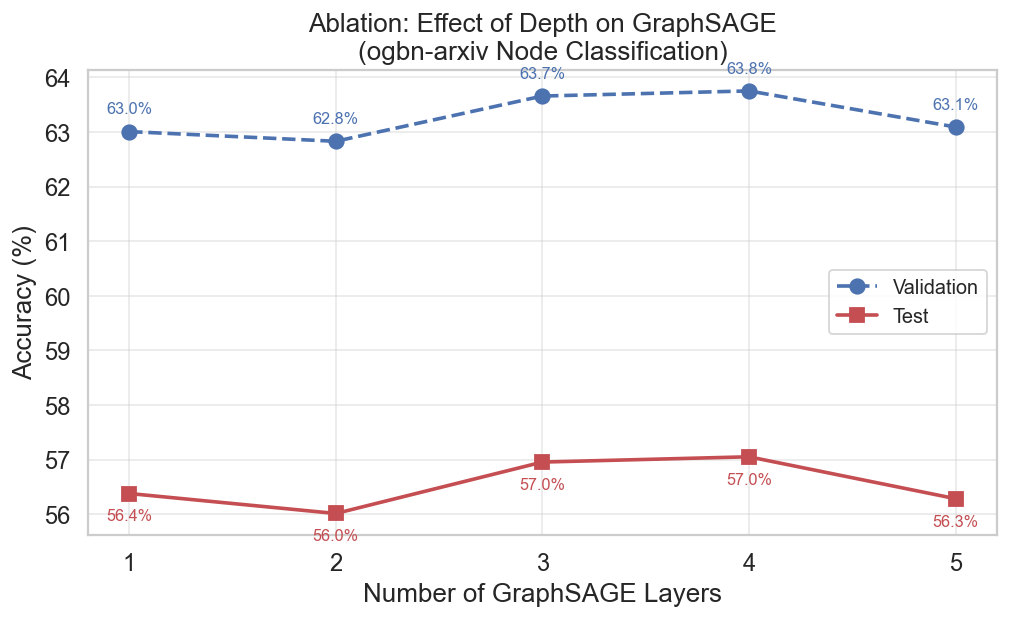

✓ Saved → reports/figures/depth_ablation.png


In [12]:
layers_list = sorted(depth_results.keys())
val_scores  = [depth_results[l]["val"]  * 100 for l in layers_list]
test_scores = [depth_results[l]["test"] * 100 for l in layers_list]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(layers_list, val_scores,  "o--", color="#4C72B0",
        linewidth=2, markersize=8, label="Validation")
ax.plot(layers_list, test_scores, "s-",  color="#C44E52",
        linewidth=2, markersize=8, label="Test")

for l, v, t in zip(layers_list, val_scores, test_scores):
    ax.annotate(f"{v:.1f}%", (l, v), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color="#4C72B0")
    ax.annotate(f"{t:.1f}%", (l, t), textcoords="offset points",
                xytext=(0, -15), ha="center", fontsize=9, color="#C44E52")

ax.set_xlabel("Number of GraphSAGE Layers")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Ablation: Effect of Depth on GraphSAGE\n(ogbn-arxiv Node Classification)")
ax.set_xticks(layers_list)
ax.legend(fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/figures/depth_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → reports/figures/depth_ablation.png")

In [13]:
print("\n" + "=" * 65)
print("FINAL EXPERIMENT SUMMARY — Graph ML Project")
print("=" * 65)
print(f"\n{'Model':<14} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12}")
print("-" * 50)
for name, r in results.items():
    print(f"{r['model']:<14} {r['test_acc']*100:>9.2f}% "
          f"{r['val_acc']*100:>9.2f}% {r['params']:>12,}")

best_model = max(results, key=lambda k: results[k]["test_acc"])
print(f"\n✓ Best model: {results[best_model]['model']} "
      f"({results[best_model]['test_acc']*100:.2f}% test accuracy)")

print(f"\nFigures saved to reports/figures/:")
for f in os.listdir("../reports/figures"):
    print(f"  ├── {f}")


FINAL EXPERIMENT SUMMARY — Graph ML Project

Model            Test Acc    Val Acc       Params
--------------------------------------------------
GCN                54.96%     60.98%      110,120
GAT                55.25%     61.99%      702,624
GRAPHSAGE          56.93%     63.82%      218,664

✓ Best model: GRAPHSAGE (56.93% test accuracy)

Figures saved to reports/figures/:
  ├── .gitkeep
  ├── depth_ablation.png
  ├── learning_curves.png
  ├── loss_curves.png
  ├── model_comparison_bar.png
